# Create a Forecast plot given a stored model

### Notebook Configuration

In [1]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'  # always print last expr.
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)

### Imports

In [2]:
import matplotlib.pyplot as plt

plt.style.use("bmh")
plt.rcParams["axes.axisbelow"] = True
import numpy as np
import pandas
import pandas as pd
from pandas import DataFrame, Index, Series, Timedelta, Timestamp
import matplotlib.dates as mdates
rng = np.random.default_rng()
np.set_printoptions()

import torch
import torchinfo
from torch import Tensor, jit, tensor
from torch.utils.data import DataLoader
from copy import deepcopy

INFO:numexpr.utils:Note: NumExpr detected 24 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


### Enter Path and Name

In [3]:
ID = (439, 15325)  # the Run_id / Experiment_id we want to plot.

# files:  2021-11-12T00:52:10 2021-11-12T00:51:55 2021-11-12T00:51:48
# "checkpoints/2021-11-15T12:05:00/LinODEnet-0"
# "checkpoints/LinODEnet/KIWI_RUNS/skew_allways/2021-11-15T16:05:41/LinODEnet-0"
# "adam/2021-11-15T20:38:52/LinODEnet-0"
PATH = "checkpoints/LinODEnet/KIWI_RUNS/"
NAME = "Long_horizon_ReZero+ResNet+AdamW+NRMSE/2021-12-17T02:18:37/LinODEnet-7"
# the model checkpoint, should be a zip-archive created by torch.save / torch.jit.save
MODEL_FILE = PATH + NAME
DEVICE = torch.device("cpu")
DTYPE = torch.float32
NAN = tensor(float("nan"), dtype=DTYPE, device=DEVICE)

tensor(nan)

## Load the Model

In [4]:
model = torch.jit.load(MODEL_FILE, torch.device("cpu"))
torchinfo.summary(model)

Layer (type:depth-idx)                                  Param #
LinODEnet                                               --
├─ConcatEmbedding: 1-1                                  113
├─ConcatProjection: 1-2                                 --
├─ResNet: 1-3                                           --
│    └─Sequential: 2-1                                  --
│    │    └─ResNetBlock: 3-1                            33,024
│    │    └─ReZero: 3-2                                 1
│    └─Sequential: 2-2                                  --
│    │    └─ResNetBlock: 3-3                            33,024
│    │    └─ReZero: 3-4                                 1
│    └─Sequential: 2-3                                  --
│    │    └─ResNetBlock: 3-5                            33,024
│    │    └─ReZero: 3-6                                 1
│    └─Sequential: 2-4                                  --
│    │    └─ResNetBlock: 3-7                            33,024
│    │    └─ReZero: 3-8              

## Import Task

In [5]:
from tsdm.tasks import KIWI_RUNS_TASK

task = KIWI_RUNS_TASK()
assert ID in task.splits[(0, "train")][0].index
TRAINLOADER = task.dataloaders[(0, "train")]
EVALLOADER = task.dataloaders[(0, "test")]

dloader = TRAINLOADER
dataset = dloader.dataset[ID]
preprocessor = deepcopy(dloader.preprocessor)
sampler = deepcopy(dloader.sampler[ID])
sampler.shuffle = False
LOADER = DataLoader(dataset, sampler=sampler)
slices = Series(LOADER)

ts = task.timeseries
ts = ts.loc[ID].astype("float32")

INFO:tsdm.config._config:Available Models: {'Latent-ODE', 'SET-TS', 'BRITS', 'TFT', 'NCDE', 'ODE-RNN', 'Informer', 'M-RNN', 'TPA', 'GRU-ODE-Bayes', 'mTAN', 'NODE', 'IP-Net', 'N-BEATS'}
INFO:tsdm.config._config:Available Datasets: {'Air Quality', 'M5', 'Traffic', 'Human Activity', 'MuJoCo', 'Electricity', 'Air Quality Multi-Site', 'M3', 'Character Trajectories', 'Household Consumption', 'tourism2', 'tourism1', 'UWAVE', 'USHCN', 'M4', 'Physionet 2012', 'Physionet 2019'}
INFO:tsdm.config._config:Initializing folder structure
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/datasets
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/models
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/logs
INFO:tsdm.config._config:creating folder /home/rscholz/.tsdm/rawdata
INFO:tsdm.config._config:Created folder structure in /home/rscholz/.tsdm
INFO:tsdm.datasets.base._base:KIWI_RUNS: START cleaning dataset!
INFO:tsdm.datasets.base._base:KIWI_RUNS/timeseries already ex

variable,Flow_Air,StirringSpeed,Temperature,Acetate,Base,Cumulated_feed_volume_glucose,Cumulated_feed_volume_medium,DOT,Glucose,OD600,Probe_Volume,pH,Fluo_GFP,InducerConcentration,Volume
measurement_time,,,,,,,,,,,,,,,
2020-12-09 09:10:09,0.0,0.0,36.389999,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN
2020-12-09 09:10:19,0.0,0.0,NaN,NaN,NaN,0.0,0.000000,0.000000,NaN,NaN,0.0,7.27,NaN,0.00,NaN
2020-12-09 09:10:24,0.0,100.0,NaN,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN
2020-12-09 09:10:25,0.0,100.0,36.130001,NaN,NaN,0.0,0.000000,NaN,NaN,NaN,0.0,NaN,NaN,0.00,NaN
2020-12-09 09:10:34,0.0,100.0,NaN,NaN,NaN,0.0,0.000000,0.000000,NaN,NaN,0.0,7.28,NaN,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-09 23:31:40,10.0,0.0,NaN,NaN,NaN,2431.0,2188.030029,52.720001,NaN,NaN,3600.0,6.44,NaN,0.05,NaN
2020-12-09 23:31:42,0.0,0.0,NaN,NaN,NaN,2431.0,2188.030029,NaN,NaN,NaN,3600.0,NaN,NaN,0.05,NaN
2020-12-09 23:31:51,0.0,0.0,NaN,NaN,NaN,2431.0,2188.030029,52.950001,NaN,NaN,3600.0,6.44,NaN,0.05,NaN


### Helper Function for Batch post-processing

In [6]:
def prep_batch(batch: tuple[Tensor, Tensor]):
    """Get batch and create model inputs and targets."""
    T, X = batch
    targets = X[..., task.observation_horizon :, task.targets.index].clone()
    # assert targets.shape == (BATCH_SIZE, PRD_HORIZON, len(TASK.targets))
    originals = X.clone()
    inputs = X.clone()
    inputs[:, task.observation_horizon :, task.targets.index] = NAN
    inputs[:, task.observation_horizon :, task.observables.index] = NAN
    # assert inputs.shape == (BATCH_SIZE, HORIZON, NUM_DIM)
    return T, inputs, targets, originals

## Helper function to create the plot

In [7]:
def make_plot(axes, task, batch):
    """Helper function to create plot automatically."""
    # batch = slices[0]
    times, inputs, targets, originals = (x.to(device="cpu") for x in prep_batch(batch))
    outputs = model(times, inputs)

    times = times[0].detach().cpu()
    inputs = inputs[0].detach().cpu()
    outputs = outputs[0].detach().cpu()
    targets = targets[0].detach().cpu()
    originals = originals[0].detach().cpu()

    times.shape, outputs.shape, inputs.shape, targets.shape, originals.shape
    reconstructed = preprocessor.decode( (times, outputs) ).astype("float32")

    for ax, (idx, target) in zip(axes.flatten(), task.targets.items()):
        color = next(ax._get_lines.prop_cycler)['color']
        data = originals[:, idx]
        mask = ~np.isnan(data)
        ax.plot(
            reconstructed.index[:task.observation_horizon],
            reconstructed.iloc[:task.observation_horizon, idx],
            ls=":",
            lw=0.5,
            color=color,
        )
        ax.plot(
            reconstructed.index[task.observation_horizon:],
            reconstructed.iloc[task.observation_horizon:, idx],
            ls="-",
            lw=0.5,
            color=color,
        )
        print(reconstructed)

### Create the Raw data plot

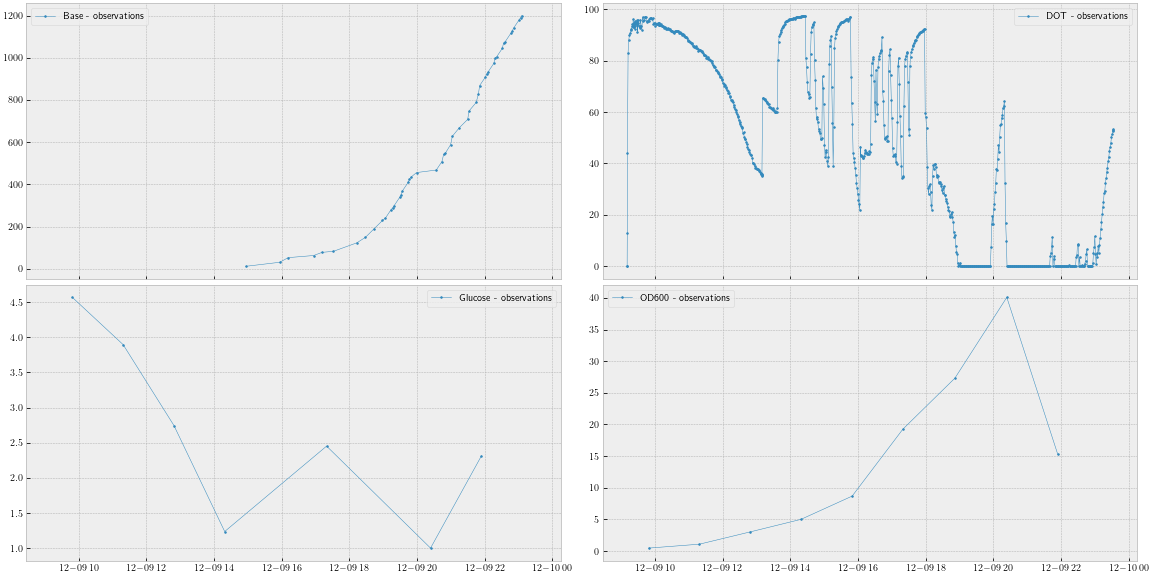

In [8]:
%matplotlib widget

fig, axes = plt.subplots(
    nrows=2, ncols=2, sharex=True, figsize=(16, 8), constrained_layout=True
)

for ax, (idx, target) in zip(axes.flatten(), task.targets.items()):
    data = ts[target]
    times = ts.index.values
    mask = ~np.isnan(data)
    ax.plot(
        times[mask],
        data[mask],
        ls="-",
        lw=0.5,
        marker=".",
        ms=3,
    )
    ax.legend([f"{target} - observations"])

### Add the model Forecast Plots

In [9]:
batches = slices.iloc[[0, 300, 600, 900, 1200]]

for batch in batches:
    make_plot(axes, task, batch)

fig.savefig(f"pics/{NAME.replace(r'/', r'_')}.pdf")

s
                     Flow_Air  StirringSpeed  Temperature   Acetate  \
measurement_time                                                      
2020-12-09 09:10:09  6.855272    -341.147705    36.933323  0.097289   
2020-12-09 09:10:19  6.748769    -319.212891    36.931156  0.096220   
2020-12-09 09:10:24  6.653239    -334.399597    36.929180  0.095174   
2020-12-09 09:10:25  6.555762    -321.077271    36.898312  0.094104   
2020-12-09 09:10:34  6.450595    -300.699402    36.896389  0.092990   
...                       ...            ...          ...       ...   
2020-12-09 09:50:50  6.847881     -87.081909    36.722706 -0.004370   
2020-12-09 09:50:59  6.849209     -87.403259    36.727570 -0.004794   
2020-12-09 09:52:02  6.863432     -94.233826    36.729969 -0.005223   
2020-12-09 09:52:11  6.864726     -94.889771    36.734951 -0.005672   
2020-12-09 09:53:13  6.879376    -101.982910    36.736912 -0.006127   

                           Base  Cumulated_feed_volume_glucose  \
measurem